In [7]:
import minari
import numpy as np
import matplotlib.pyplot as plt

dataset = minari.load_dataset("D4RL/pointmaze/large-v2", download=True)
print("Num episodes:", dataset.total_episodes)

# minari.list_remote_datasets()

Num episodes: 3360


In [8]:

# Inspect episode structure
ep = next(dataset.iterate_episodes())
print("obs keys:", ep.observations.keys())
print("obs['observation'] shape:", ep.observations['observation'].shape)
print("obs sample:", ep.observations['observation'][0])


obs keys: dict_keys(['achieved_goal', 'desired_goal', 'observation'])
obs['observation'] shape: (289, 4)
obs sample: [ 2.34218591 -1.16204705  0.          0.        ]


In [10]:

# Extract the true maze map and cell size directly from the gym environment
import gymnasium as gym
import gymnasium_robotics
import numpy as np

env = gym.make("PointMaze_Large-v3")
maze = env.unwrapped.maze
LARGE_MAZE = maze.maze_map          # list[list[int]]
cell_size  = maze.maze_size_scaling  # world units per cell
env.close()

print("cell_size:", cell_size)
print("maze shape:", len(LARGE_MAZE), "x", len(LARGE_MAZE[0]))
for row in LARGE_MAZE:
    print(row)


cell_size: 1
maze shape: 9 x 12
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1]
[1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1]
[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1]
[1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1]
[1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1]
[1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1]
[1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


min: 2,  max: 798,  mean: 298.6,  median: 291


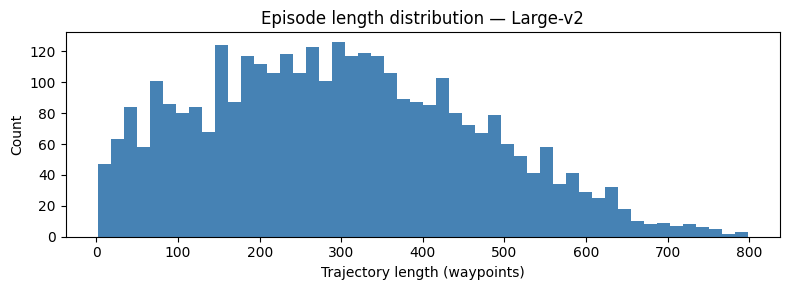

In [11]:

# Check episode length distribution across ALL episodes
lengths = [ep.observations['observation'].shape[0] for ep in dataset.iterate_episodes()]
lengths = np.array(lengths)
print(f"min: {lengths.min()},  max: {lengths.max()},  mean: {lengths.mean():.1f},  median: {np.median(lengths):.0f}")

plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='none')
plt.xlabel('Trajectory length (waypoints)')
plt.ylabel('Count')
plt.title('Episode length distribution — Large-v2')
plt.tight_layout()
plt.show()


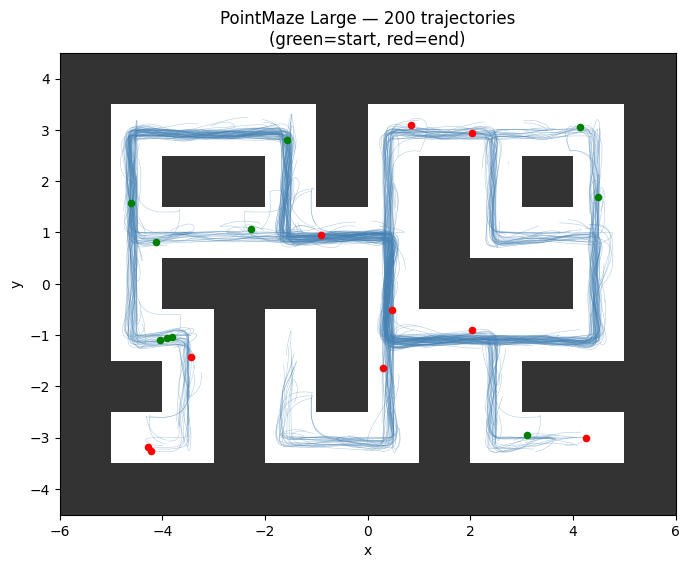

In [12]:

import matplotlib.pyplot as plt
import matplotlib.patches as patches

# LARGE_MAZE and cell_size loaded from the gym environment in the cell above
n_rows, n_cols = len(LARGE_MAZE), len(LARGE_MAZE[0])

def cell_to_xy(row, col):
    """Center of maze cell in 2D world coords."""
    x = (col - (n_cols - 1) / 2) * cell_size
    y = ((n_rows - 1) / 2 - row) * cell_size
    return x, y

# Sample N episodes for plotting
N_TRAJS = 200
episodes = dataset.sample_episodes(N_TRAJS)

fig, ax = plt.subplots(figsize=(7, 7))

# Draw maze walls
for r in range(n_rows):
    for c in range(n_cols):
        if LARGE_MAZE[r][c] == 1:
            cx, cy = cell_to_xy(r, c)
            rect = patches.Rectangle(
                (cx - cell_size / 2, cy - cell_size / 2),
                cell_size, cell_size,
                linewidth=0, facecolor='#333333'
            )
            ax.add_patch(rect)

# Plot trajectories
for ep in episodes:
    xy = ep.observations['observation'][:, :2]
    ax.plot(xy[:, 0], xy[:, 1], lw=0.4, alpha=0.4, color='steelblue')

# Mark start & goal of a few episodes
for ep in list(episodes)[:10]:
    xy = ep.observations['observation'][:, :2]
    ax.scatter(xy[0, 0], xy[0, 1], c='green', s=20, zorder=5)
    ax.scatter(xy[-1, 0], xy[-1, 1], c='red', s=20, zorder=5)

ax.set_xlim(-n_cols / 2 * cell_size, n_cols / 2 * cell_size)
ax.set_ylim(-n_rows / 2 * cell_size, n_rows / 2 * cell_size)
ax.set_aspect('equal')
ax.set_title(f'PointMaze Large — {N_TRAJS} trajectories\n(green=start, red=end)')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
plt.show()


In [13]:

import torch

# ── Config ────────────────────────────────────────────────────────────────────
HORIZON      = 64       # change freely — spatial shape stays the same
GOAL_THRESH  = 0.5      # episode must reach within this distance of its goal

# ── Resample helper ───────────────────────────────────────────────────────────
def resample(obs, H):
    """Uniformly resample a [T, D] trajectory to [H, D] via linear interp."""
    T = len(obs)
    t_src = np.linspace(0, 1, T)
    t_dst = np.linspace(0, 1, H)
    return np.stack([np.interp(t_dst, t_src, obs[:, d])
                     for d in range(obs.shape[1])], axis=-1)  # [H, D]

# ── 1. Filter + resample — one trajectory per episode ─────────────────────────
clean = []
for ep in dataset.iterate_episodes():
    obs  = ep.observations['observation']        # [T, 4]: x, y, vx, vy
    goal = ep.observations['desired_goal']       # [T, 2]
    if np.linalg.norm(obs[:, :2] - goal, axis=-1).min() < GOAL_THRESH:
        clean.append(resample(obs[:, :2], HORIZON))  # x,y only → [H, 2]

print(f"Clean episodes: {len(clean)}")
windows = np.stack(clean, axis=0)                # [N, H, 2]
print(f"Total trajectories: {windows.shape}")

# ── 2. Normalize to [-1, 1] ────────────────────────────────────────────────────
flat  = windows.reshape(-1, 2)
d_min = flat.min(axis=0)                         # [2]
d_max = flat.max(axis=0)                         # [2]

def normalize(x):   return 2.0 * (x - d_min) / (d_max - d_min + 1e-8) - 1.0
def unnormalize(x): return (x + 1.0) / 2.0 * (d_max - d_min) + d_min

normed = normalize(windows)
print(f"Normed range — min: {normed.min():.3f}, max: {normed.max():.3f}")

# ── 3. PyTorch tensor ─────────────────────────────────────────────────────────
trajectories = torch.tensor(normed, dtype=torch.float32)  # [N, H, 2]
print(f"trajectories tensor: {trajectories.shape}")


Clean episodes: 3360
Total trajectories: (3360, 64, 2)
Normed range — min: -1.000, max: 1.000
trajectories tensor: torch.Size([3360, 64, 2])


In [14]:

import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))  # make SafeDPMSolverProject importable
from Diffuser.maze_dataset import save_dataset

save_dataset(
    trajectories,
    d_min, d_max,
    data_dir  = "data/large_v2",
    env_id    = "D4RL/pointmaze/large-v2",
    horizon   = HORIZON,
    goal_thresh = GOAL_THRESH,
    maze_map  = LARGE_MAZE,
    cell_size = cell_size,
)


Saved 3360 windows → data/large_v2/
  trajectories.pt : (3360, 64, 2)  float32
  metadata.json   : horizon=64, obs_dim=2, norm_min=[-4.829 -3.334], norm_max=[4.797 3.315]


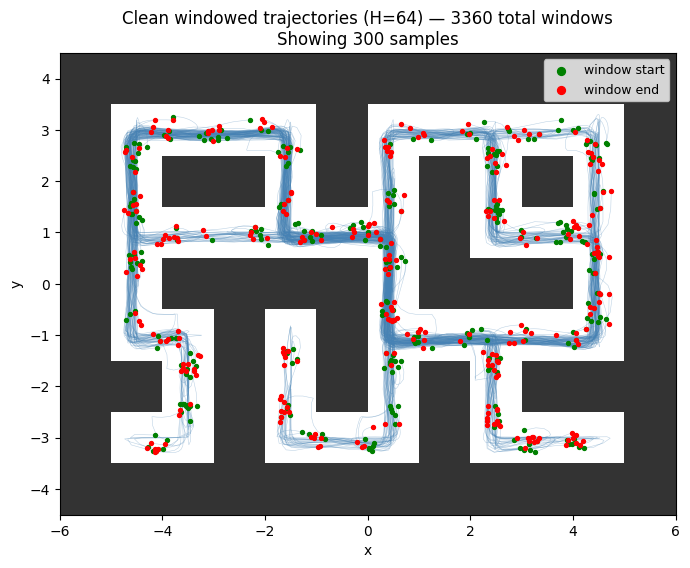

In [15]:

# Plot a sample of cleaned, windowed trajectories in world coordinates
N_PLOT = 300
idx = np.random.choice(len(trajectories), size=min(N_PLOT, len(trajectories)), replace=False)
sample = unnormalize(trajectories[idx].numpy())  # [N_PLOT, H, 2] — world coords

fig, ax = plt.subplots(figsize=(7, 7))

# Draw maze walls
for r in range(n_rows):
    for c in range(n_cols):
        if LARGE_MAZE[r][c] == 1:
            cx, cy = cell_to_xy(r, c)
            ax.add_patch(patches.Rectangle(
                (cx - cell_size / 2, cy - cell_size / 2),
                cell_size, cell_size,
                linewidth=0, facecolor='#333333'
            ))

# Draw trajectories
for traj in sample:
    ax.plot(traj[:, 0], traj[:, 1], lw=0.4, alpha=0.35, color='steelblue')

# Mark start (green) and end (red) of each window
ax.scatter(sample[:, 0, 0],  sample[:, 0, 1],  c='green', s=8, zorder=5, label='window start')
ax.scatter(sample[:, -1, 0], sample[:, -1, 1], c='red',   s=8, zorder=5, label='window end')

ax.set_xlim(-n_cols / 2 * cell_size, n_cols / 2 * cell_size)
ax.set_ylim(-n_rows / 2 * cell_size, n_rows / 2 * cell_size)
ax.set_aspect('equal')
ax.legend(markerscale=2, fontsize=9)
ax.set_title(f'Clean windowed trajectories (H={HORIZON}) — {len(trajectories)} total windows\n'
             f'Showing {min(N_PLOT, len(trajectories))} samples')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
plt.show()
